# Chapter 2 - Supervised Learning
Implementasi lengkap dengan visualisasi dan evaluasi model.


## 2.1 Import Library

In [30]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

## 2.2 Dataset Sintetis (Blobs)

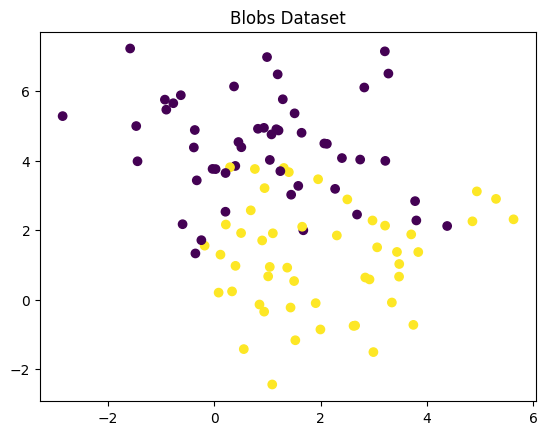

In [31]:
X_blob, y_blob = make_blobs(n_samples=100, centers=2, random_state=0, cluster_std=1.5)

plt.scatter(X_blob[:,0], X_blob[:,1], c=y_blob)
plt.title('Blobs Dataset')
plt.show()

## 2.3 Dataset Non-Linear (Moons)

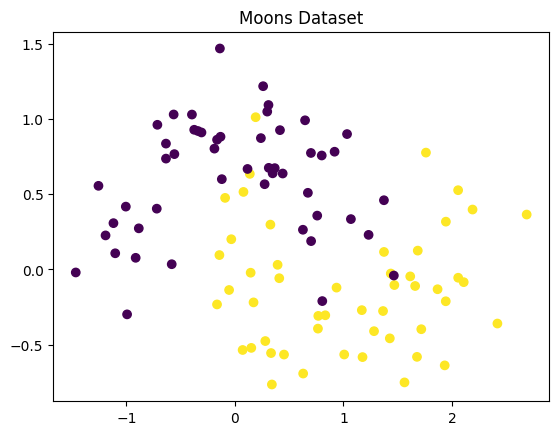

In [32]:
X_moon, y_moon = make_moons(n_samples=100, noise=0.25, random_state=42)

plt.scatter(X_moon[:,0], X_moon[:,1], c=y_moon)
plt.title('Moons Dataset')
plt.show()

## 2.4 KNN Model

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X_blob, y_blob, random_state=0)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

print('Accuracy:', knn.score(X_test, y_test))

Accuracy: 0.72


## 2.5 Decision Boundary

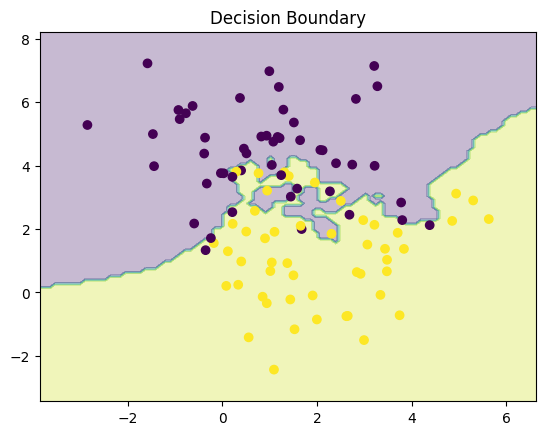

In [34]:
xx, yy = np.meshgrid(
    np.linspace(X_blob[:,0].min()-1, X_blob[:,0].max()+1, 100),
    np.linspace(X_blob[:,1].min()-1, X_blob[:,1].max()+1, 100)
)

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_blob[:,0], X_blob[:,1], c=y_blob)
plt.title('Decision Boundary')
plt.show()

## 2.6 Pengaruh Nilai K

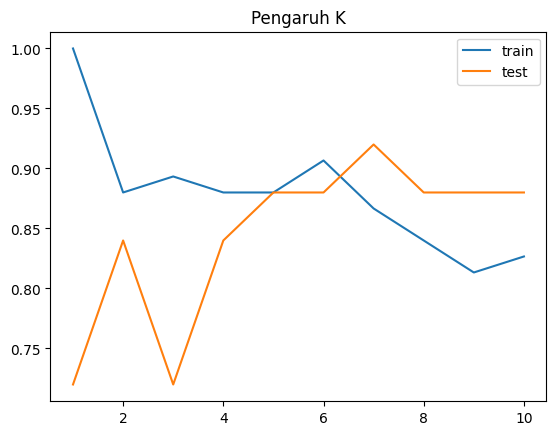

In [35]:
train_acc = []
test_acc = []

neighbors = range(1,11)

for n in neighbors:
    model = KNeighborsClassifier(n_neighbors=n)
    model.fit(X_train, y_train)
    train_acc.append(model.score(X_train, y_train))
    test_acc.append(model.score(X_test, y_test))

plt.plot(neighbors, train_acc, label='train')
plt.plot(neighbors, test_acc, label='test')
plt.legend()
plt.title('Pengaruh K')
plt.show()

## 2.7 Dataset Breast Cancer

In [36]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42
)

## 2.8 Scaling

In [37]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 2.9 Logistic Regression

In [38]:
logreg = LogisticRegression(max_iter=5000)
logreg.fit(X_train, y_train)

print('Train:', logreg.score(X_train, y_train))
print('Test:', logreg.score(X_test, y_test))

Train: 0.9882629107981221
Test: 0.986013986013986


## 2.10 Evaluation

In [39]:
y_pred = logreg.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[52  1]
 [ 1 89]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        53
           1       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



## 2.11 Decision Tree

In [40]:
tree = DecisionTreeClassifier(max_depth=4, random_state=0)
tree.fit(X_train, y_train)

print('Train:', tree.score(X_train, y_train))
print('Test:', tree.score(X_test, y_test))

Train: 0.9882629107981221
Test: 0.951048951048951


## 2.12 Feature Importance

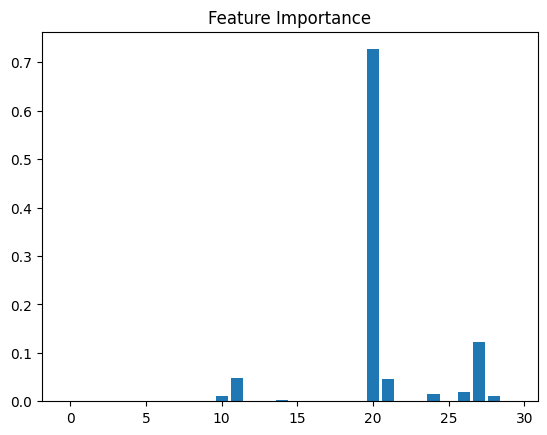

In [41]:
plt.bar(range(len(tree.feature_importances_)), tree.feature_importances_)
plt.title('Feature Importance')
plt.show()